In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib inline

pdf = PdfPages('movies_pdf.pdf')

In [2]:
df_movies = pd.read_csv('../../../data/raw/lecture/tmdb_5000_movies.csv')
df_credits = pd.read_csv('../../../data/raw/lecture/tmdb_5000_credits.csv')

In [3]:
df = df_movies.merge(df_credits,
                     left_on='id',
                     right_on='movie_id',
                     suffixes=('_movies', '_credits'))
df.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_movies,vote_average,vote_count,movie_id,title_credits,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [4]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count,movie_id
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989,57165.484281
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891,88694.614033
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,5.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000,9014.500000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000,14629.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000,58610.500000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000,459488.000000


In [8]:
df = df[(df['revenue'] != 0) & (df['budget'] != 0)]
len(df)

3229

In [15]:
df = df[df['vote_average'] != 0]
len(df)

3227

In [16]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count,movie_id
count,3.227000e+03,3227.000000,3227.000000,3.227000e+03,3227.000000,3227.000000,3227.000000,3227.000000
mean,4.067877e+07,44601.870778,29.051491,1.213181e+08,110.720793,6.313263,977.893090,44601.870778
std,4.439974e+07,74281.771931,36.169863,1.863361e+08,20.970364,0.859921,1414.538507,74281.771931
min,1.000000e+00,5.000000,0.019984,5.000000e+00,41.000000,2.300000,1.000000,5.000000
25%,1.050000e+07,4954.500000,10.475904,1.704008e+07,96.000000,5.800000,178.000000,4954.500000
50%,2.500000e+07,11442.000000,20.415572,5.519828e+07,107.000000,6.300000,471.000000,11442.000000
75%,5.500000e+07,45256.000000,37.345773,1.463949e+08,121.000000,6.900000,1148.000000,45256.000000
max,3.800000e+08,417859.000000,875.581305,2.787965e+09,338.000000,8.500000,13752.000000,417859.000000


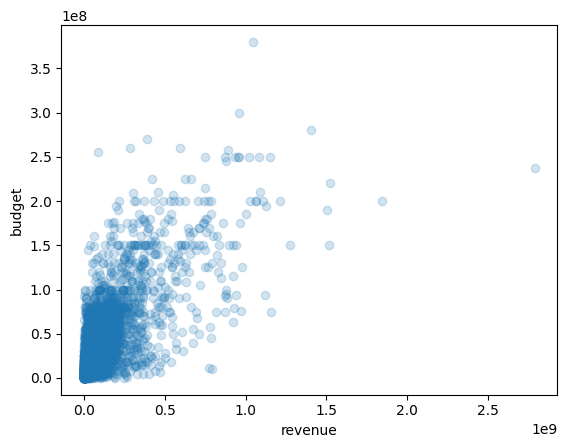

In [66]:
fig, axes = plt.subplots()
axes.scatter('revenue', 'budget', data=df, alpha=0.2)
axes.set_xlabel('revenue')
axes.set_ylabel('budget')
pdf.savefig(fig)
pdf.close()

In [29]:
lang_group_df = df.groupby('original_language').mean(numeric_only=True)[['budget', 'revenue', 'vote_count']]
lang_group_df.head(3)

,budget,revenue,vote_count
original_language,,,
af,3000000.0,9879971.0,94.00
cn,19843390.6,62960727.8,327.00
da,15100000.0,52323054.0,703.25


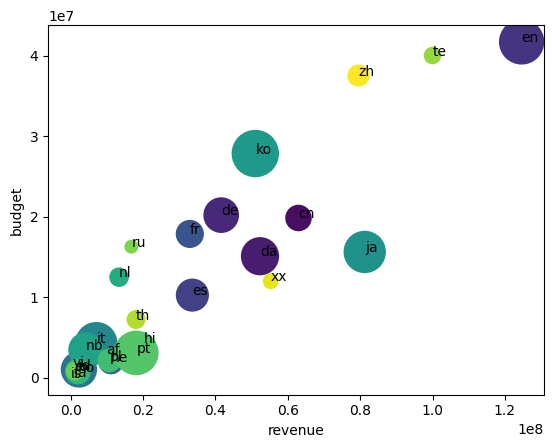

In [67]:
fig, axes = plt.subplots()
axes.scatter('revenue', 'budget',
             s='vote_count',
             c=np.arange(len(lang_group_df)),
             data=lang_group_df)
for idx, row in lang_group_df.iterrows():
    axes.annotate(idx, (row['revenue'], row['budget']))

axes.set_xlabel('revenue')
axes.set_ylabel('budget')
pdf.savefig(fig)
pdf.close()

In [44]:
df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title_movies', 'vote_average',
       'vote_count', 'movie_id', 'title_credits', 'cast', 'crew'],
      dtype='str')

In [46]:
df['profit'] = df['revenue'] - df['budget']
df['profit']

0       2550965087
1        661000000
2        635674609
3        834939099
4         24139100
           ...    
4773       3124130
4788       5988000
4792         79000
4796        417760
4798       1820920
Name: profit, Length: 3227, dtype: int64

In [49]:
df.groupby('original_language').max()['profit']

original_language
af       6879971
cn     120844753
da     135000000
de      74584880
en    2550965087
es      93567206
fa        720000
fr     163921954
he       9125849
hi      38300000
id       3005187
is             1
it      14300000
ja     259925095
ko      77489643
nb        659678
nl       5193068
no       1184662
pl       8540720
pt      27341770
ro        333273
ru      27800000
te      60000000
th      21165581
vi       -661000
xx      43260558
zh     196525736
Name: profit, dtype: int64

In [59]:
logbins = np.logspace(5, np.log10(df['profit'].max()), 100)
logbins

array([1.00000000e+05, 1.10792960e+05, 1.22750801e+05, 1.35999246e+05,
       1.50677591e+05, 1.66940163e+05, 1.84957949e+05, 2.04920387e+05,
       2.27037363e+05, 2.51541416e+05, 2.78690181e+05, 3.08769102e+05,
       3.42094429e+05, 3.79016545e+05, 4.19923651e+05, 4.65245844e+05,
       5.15459644e+05, 5.71092999e+05, 6.32730840e+05, 7.01021228e+05,
       7.76682172e+05, 8.60509171e+05, 9.53383585e+05, 1.05628190e+06,
       1.17028598e+06, 1.29659449e+06, 1.43653542e+06, 1.59158011e+06,
       1.76335872e+06, 1.95367733e+06, 2.16453695e+06, 2.39815457e+06,
       2.65698644e+06, 2.94375393e+06, 3.26147213e+06, 3.61348152e+06,
       4.00348315e+06, 4.43557750e+06, 4.91430763e+06, 5.44470690e+06,
       6.03235196e+06, 6.68342132e+06, 7.40476033e+06, 8.20395318e+06,
       9.08940259e+06, 1.00704182e+07, 1.11573145e+07, 1.23615190e+07,
       1.36956928e+07, 1.51738635e+07, 1.68115726e+07, 1.86260390e+07,
       2.06363400e+07, 2.28636120e+07, 2.53312726e+07, 2.80652668e+07,
      

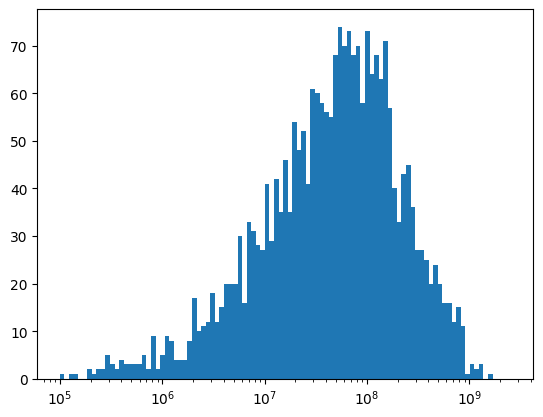

In [60]:
plt.hist(df['profit'], bins=logbins)
plt.xscale('log')
plt.show()

In [63]:
pdf.savefig